<a href="https://colab.research.google.com/github/Yahya1805/machine-learning_2026/blob/main/ML_JS04_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
df = pd.read_csv('Iris.csv')

In [9]:
# Persiapan data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Iris.csv')
# Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### 2. Seleksi Fitur

**Kode**

Pada langkah ini, kita menampilkan 5 data teratas dari fitur yang telah diseleksi (`X.head()`). Fitur yang digunakan adalah `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, dan `PetalWidthCm`.

In [10]:
# Menampilkan 5 data pertama dari fitur hasil seleksi
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 3. Plot Data

**Kode**

Kita membuat scatter plot awal menggunakan fitur `SepalLengthCm` (index 0) dan `SepalWidthCm` (index 1) untuk melihat sebaran data mentah sebelum dikelompokkan oleh algoritma KMeans.

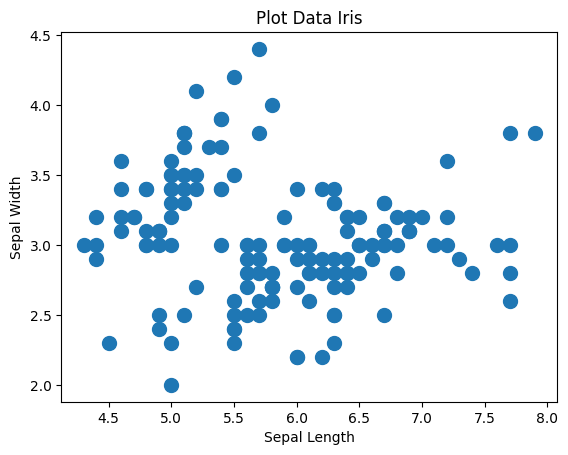

In [11]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s=100)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Plot Data Iris")
plt.show()

### 4. Membuat Model KMeans k=2

**Kode**

Kita membuat objek model KMeans dengan menentukan jumlah cluster `k=2` dan melatih model tersebut sekaligus melakukan prediksi pengelompokkan pada data `X`.

In [12]:
from sklearn.cluster import KMeans

cl_kmeans = KMeans(n_clusters=2, random_state=42)
y_kmeans = cl_kmeans.fit_predict(X)

### 5. Plot Hasil Cluster

**Kode**

Menampilkan visualisasi hasil clustering dengan membagi data menjadi dua warna berdasarkan kelompok (`y_kmeans`) dan menggambarkan pusat cluster (centroid) berwarna merah.

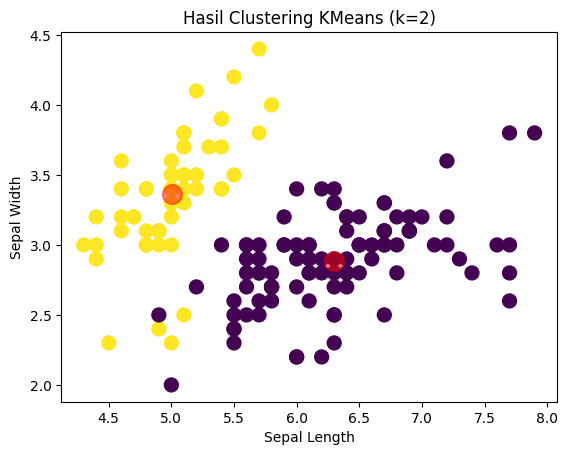

In [13]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s=100, c=y_kmeans)

centers = cl_kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    s=200,
    alpha=0.5
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Hasil Clustering KMeans (k=2)")
plt.show()

### 6. Nilai SSE

**Kode**

Menghitung nilai SSE (Sum of Squared Errors) dari model KMeans dengan `k=2` menggunakan properti `.inertia_`.

In [14]:
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


Analisis Hasil

**A. Hasil KMeans k=2**
* Hasil pengelompokan data dengan `k=2` membagi seluruh dataset Iris ke dalam 2 cluster besar.
* Centroid (titik merah) menjadi pusat penentu dari masing-masing klaster berdasarkan perhitungan jarak terpendek.
* Variabel `y_kmeans` bertugas menampung nilai label kelas hasil prediksi model (0 atau 1).

**B. SSE (Sum of Squared Errors)**
* Nilai SSE merepresentasikan jumlah kuadrat jarak antara data dengan pusat clusternya.
* Semakin kecil nilai SSE, semakin rapat sebaran data di dalam cluster tersebut terhadap pusatnya.

**C. Metode Elbow**
* Ketika jumlah cluster ($k$) bertambah besar, nilai SSE akan semakin kecil karena data akan selalu berada lebih dekat ke pusat cluster baru.
* Cara membaca grafik Elbow adalah dengan melihat titik siku di mana grafik tersebut mulai melandai secara drastis.

**D. Jumlah Cluster**
* Dari grafik Elbow hasil eksekusi praktikum, penurunan tajam terjadi hingga titik $k=3$, dan setelah $k=3$ penurunan nilai SSE menjadi sangat landai. Dengan demikian, jumlah cluster terbaik yang dipilih adalah **3 cluster**.

Kesimpulan

1. KMeans merupakan algoritma clustering yang masuk ke dalam metode *unsupervised learning*.
2. KMeans mengelompokkan data ke dalam sejumlah cluster berdasarkan kedekatan jarak fitur dengan nilai $k$ yang telah ditentukan.
3. Centroid merupakan representasi titik pusat dari sebuah kelompok cluster.
4. SSE (Sum of Squared Errors) digunakan sebagai metrik evaluasi untuk mengetahui tingkat kesalahan pengelompokan.
5. Metode Elbow sangat efektif dalam menentukan jumlah cluster ($k$) optimal secara matematis.
6. Berdasarkan hasil pengujian grafik Elbow pada data Iris ini, jumlah cluster terbaik yang disarankan adalah **3 cluster**.

### 7. Implementasi Metode Elbow

**Kode**

Kita membuat sebuah list kosong bernama `sse` untuk menyimpan nilai inertia/SSE dari model KMeans dengan variasi jumlah cluster `k` dari 1 sampai 9 (`range(1, 10)`).

In [15]:
sse = []
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42)
    kmeanModel.fit(X)
    sse.append(kmeanModel.inertia_)

### 8. Plot Grafik Elbow

**Kode**

Membuat grafik garis yang menghubungkan nilai $k$ dengan nilai SSE yang dihasilkan untuk membantu menentukan titik siku (elbow) terbaik.

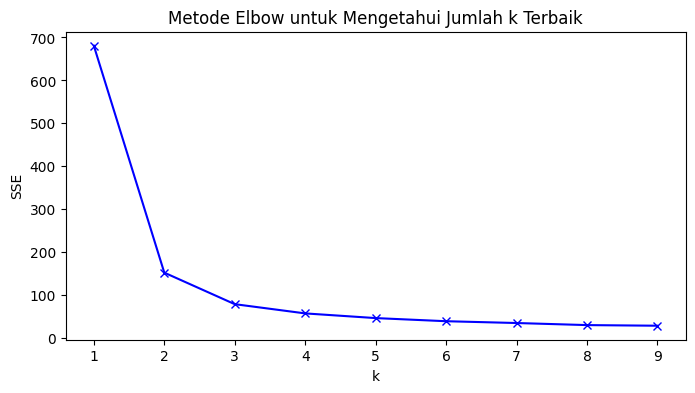

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

### 9. SSE Setiap k

**Kode**

Menampilkan secara detail nilai SSE konkret yang didapatkan untuk setiap konfigurasi jumlah cluster $k$ dari 1 sampai 9.

In [17]:
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94506582597728
k=4; SSE=57.44028021295475
k=5; SSE=46.535582051282034
k=6; SSE=39.251830892636775
k=7; SSE=35.04275995246584
k=8; SSE=30.217021122152712
k=9; SSE=28.7564561965812
